<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/Voronoi_Power_Diagram_View.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Any, Dict, List, Optional

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------------------
# Assumed existing types (not redefined here):
#
# - DiagramConfig
# - Node (label: str, weight: float, children: Dict[str, Node])
# - Site (label: str, p: np.ndarray, w: float)
# - PolygonOps with:
#       bbox(xmin, xmax, ymin, ymax)
#       polygon_centroid(poly)
#       poly_diag(poly)
#       polygon_area(poly)
#       close(poly)
# - PowerDiagram with:
#       cell(site, sites, domain)
#       auto_scale(weights, length)
# - HierarchyParser.parse(hierarchy), Dict[str, Node]
#
# Poly is assumed to be a list or array of 2D points.
# --------------------------------------------------------------------------------------

Point = np.ndarray
Poly = List[Point]


# ======================================================================================
# 1) Weight Propagation
# ======================================================================================

class WeightPropagator:
    """
    Responsible for enforcing hierarchical weight consistency.

    Requirement:
        Parent node weights must equal the sum of their children’s weights.

    This ensures that:
        - Top-level area targets are consistent with leaf weights.
        - Area constraints remain coherent across nested levels.
    """

    @staticmethod
    def propagate_node(node: "Node") -> float:
        """
        Recursively propagate weights upward.

        If a node has children:
            Its weight becomes the sum of child weights.

        If a node is a leaf:
            Its weight remains unchanged.

        Returns
        -------
        float
            The updated weight of the node.
        """
        if not node.children:
            return node.weight

        total = 0.0
        for child in node.children.values():
            total += WeightPropagator.propagate_node(child)

        node.weight = float(total)
        return node.weight

    def propagate_roots(self, roots: Dict[str, "Node"]) -> None:
        """
        Apply propagation to all root nodes.
        """
        for node in roots.values():
            self.propagate_node(node)


# ======================================================================================
# 2) Domain Construction Helper
# ======================================================================================

@dataclass(frozen=True)
class DiagramDomain:
    """
    Represents the rectangular bounding domain used for the top-level diagram.

    This domain defines:
        - Plot axis limits
        - Clipping region for power diagram computation
    """
    xmin: float
    xmax: float
    ymin: float
    ymax: float
    poly: Poly  # Polygon representation of bounding box

    @staticmethod
    def from_config(cfg: "DiagramConfig", ops: "PolygonOps") -> "DiagramDomain":
        """
        Build the bounding box domain from configuration parameters.

        Padding ensures that cells near the boundary do not clip visually.
        """
        xmin = -cfg.radius - cfg.padding
        xmax =  cfg.radius + cfg.padding
        ymin = -cfg.radius - cfg.padding
        ymax =  cfg.radius + cfg.padding

        bbox_poly = ops.bbox(xmin, xmax, ymin, ymax)

        return DiagramDomain(xmin, xmax, ymin, ymax, bbox_poly)


# ======================================================================================
# 3) Layout Engine
# ======================================================================================

class LevelLayouter:
    """
    Generates initial site positions and weights for a hierarchy level.

    Responsibilities:
        - Arrange nodes in a ring around a center
        - Apply random jitter
        - Scale weights to appropriate magnitude
    """

    def __init__(self, cfg: "DiagramConfig", rng: np.random.Generator, pd: "PowerDiagram"):
        self.cfg = cfg
        self.rng = rng
        self.pd = pd

    def layout_level(
        self,
        nodes: List["Node"],
        center: Point,
        length: float,
        jitter: float,
        weight_scale: Optional[float],
    ) -> List["Site"]:
        """
        Create initial power diagram sites for a given set of nodes.

        Parameters
        ----------
        nodes:
            Nodes at this hierarchy level.
        center:
            Center of ring layout.
        length:
            Radius of the ring.
        jitter:
            Gaussian noise magnitude for breaking symmetry.
        weight_scale:
            Optional scaling factor for site weights.

        Returns
        -------
        List[Site]
            Initial site objects for power diagram solving.
        """
        labels = [n.label for n in nodes]
        raw_weights = np.array([n.weight for n in nodes], dtype=float)

        # If no explicit weight scale is provided,
        # use an automatic scaling heuristic from PowerDiagram.
        scale = weight_scale or self.pd.auto_scale(raw_weights, max(length, 1e-6))

        # Initial effective weights
        w0 = raw_weights * scale

        # Even angular distribution around circle
        if len(nodes) > 1:
            angles = np.linspace(0, 2 * math.pi, len(nodes), endpoint=False)
        else:
            angles = np.array([0.0])

        # Compute ring coordinates
        pts = np.c_[np.cos(angles), np.sin(angles)] * length + center

        # Add small Gaussian perturbation
        pts += self.rng.normal(0.0, jitter, size=pts.shape)

        return [
            Site(labels[i], pts[i].astype(float), float(w0[i]))
            for i in range(len(nodes))
        ]


# ======================================================================================
# 4) Power Diagram Solver (Area-Constrained)
# ======================================================================================

class LevelSolver:
    """
    Solves a power diagram within a domain.

    Features:
        - Lloyd relaxation (optional)
        - Area-constrained weight adjustment
        - Iterative convergence control
    """

    def __init__(self, cfg: "DiagramConfig", ops: "PolygonOps", pd: "PowerDiagram"):
        self.cfg = cfg
        self.ops = ops
        self.pd = pd

    def solve_level(self, sites: List["Site"], nodes: List["Node"], domain: Poly) -> Dict[str, Poly]:
        """
        Compute power diagram cells with optional area constraints.

        Algorithm Overview
        ------------------
        1. Compute target areas proportional to node weights.
        2. Optionally apply Lloyd relaxation to smooth shapes.
        3. Iteratively adjust site weights to match target areas.
        4. Return final cell polygons.
        """

        # ------------------------------------------------------------------
        # Step 1: Compute target areas
        # ------------------------------------------------------------------
        domain_area = abs(self.ops.polygon_area(domain))
        raw = np.array([n.weight for n in nodes], dtype=float)

        if np.all(raw <= 0):
            raw = np.ones_like(raw)

        raw = np.maximum(raw, 0.0)
        target_areas = (raw / raw.sum()) * domain_area

        label_to_idx = {nodes[i].label: i for i in range(len(nodes))}

        def compute_cells():
            return {s.label: self.pd.cell(s, sites, domain) for s in sites}

        def compute_areas(cells):
            areas = np.zeros(len(nodes))
            for lbl, poly in cells.items():
                i = label_to_idx[lbl]
                areas[i] = abs(self.ops.polygon_area(poly))
            return areas

        # ------------------------------------------------------------------
        # Step 2: Lloyd Relaxation
        # ------------------------------------------------------------------
        for _ in range(max(0, int(self.cfg.lloyd_iters))):
            cells = compute_cells()
            for s in sites:
                poly = cells.get(s.label, [])
                if poly and len(poly) >= 3:
                    s.p = self.ops.polygon_centroid(poly)

        # ------------------------------------------------------------------
        # Step 3: Area-Constrained Weight Adjustment
        # ------------------------------------------------------------------
        if self.cfg.area_constrained and len(sites) > 1:

            diag = max(1e-6, self.ops.poly_diag(domain))
            step_scale = (diag * diag) / max(domain_area, 1e-9)

            for _ in range(max(1, int(self.cfg.area_iters))):

                cells = compute_cells()
                current = compute_areas(cells)

                rel_err = np.mean(np.abs(current - target_areas) / (target_areas + 1e-9))

                if rel_err < self.cfg.area_tol:
                    break

                delta = (target_areas - current) * (self.cfg.area_lr * step_scale)

                for s in sites:
                    idx = label_to_idx[s.label]
                    s.w += float(delta[idx])

        # ------------------------------------------------------------------
        # Final result
        # ------------------------------------------------------------------
        return compute_cells()


# ======================================================================================
# 5) Rendering Helpers
# ======================================================================================

class CentroidColoring:
    """
    Color polygons from a 3D projection of their centroid coordinates.
    Steps:
      1) normalize centroid x,y to [-1,1] using the current domain bbox
      2) lift to 3D with z = f(x,y)
      3) rotate in 3D (projection)
      4) normalize projected coords to [0,1] -> RGB
    """

    @staticmethod
    def _rotation_matrix(ax: float, ay: float, az: float) -> np.ndarray:
        cx, sx = math.cos(ax), math.sin(ax)
        cy, sy = math.cos(ay), math.sin(ay)
        cz, sz = math.cos(az), math.sin(az)

        Rx = np.array([[1, 0, 0],
                       [0, cx, -sx],
                       [0, sx, cx]], float)
        Ry = np.array([[cy, 0, sy],
                       [0, 1, 0],
                       [-sy, 0, cy]], float)
        Rz = np.array([[cz, -sz, 0],
                       [sz,  cz, 0],
                       [0,   0,  1]], float)

        return Rz @ Ry @ Rx

    @staticmethod
    def centroids_to_rgb(
        centroids_xy: np.ndarray,
        domain_bbox: tuple[float, float, float, float],
        *,
        angles: tuple[float, float, float] = (0.5, 0.5, 0.5),
        eps: float = 1e-12,
    ) -> np.ndarray:
        """
        centroids_xy: (N,2)
        domain_bbox: (xmin, xmax, ymin, ymax)
        returns rgb: (N,3) in [0,1]
        """
        xmin, xmax, ymin, ymax = domain_bbox

        x = centroids_xy[:, 0]
        y = centroids_xy[:, 1]

        # normalize to [-1,1] for stability across scales
        xn = 2.0 * (x - xmin) / max(xmax - xmin, eps) - 1.0
        yn = 2.0 * (y - ymin) / max(ymax - ymin, eps) - 1.0

        # lift to 3D using centroid coords only
        zn = 0.5 * (xn + yn)

        P = np.stack([xn, yn, zn], axis=1)  # (N,3)

        R = CentroidColoring._rotation_matrix(*angles)
        Q = (R @ P.T).T  # (N,3)

        # normalize each channel to [0,1] across this draw call
        qmin = Q.min(axis=0)
        qmax = Q.max(axis=0)
        rgb = (Q - qmin) / (qmax - qmin + eps)
        return np.clip(rgb, 0.0, 1.0)

class CellDrawer:
    """
    Handles all matplotlib drawing.

    Responsibilities:
        - Draw cell polygons
        - Place centroid-centered labels
    """

    def __init__(self, ops: "PolygonOps"):
        self.ops = ops

    def _bbox_of_domain(self, domain_poly: Poly) -> tuple[float, float, float, float]:
        arr = np.asarray(domain_poly, float)
        xmin = float(arr[:, 0].min())
        xmax = float(arr[:, 0].max())
        ymin = float(arr[:, 1].min())
        ymax = float(arr[:, 1].max())
        return xmin, xmax, ymin, ymax

    def draw_cells(self, ax, sites, cells, *, alpha, lw, domain_poly: Optional[Poly] = None):
        """
        Draw filled polygons with outlines, shaded by 3D-projected centroid color.

        domain_poly:
            The polygon defining the domain used for normalization. If omitted,
            we fall back to the current axes limits (less ideal but works).
        """
        # --- gather valid polygons + centroids (two-pass so colors normalize globally)
        polys: List[Poly] = []
        centroids: List[np.ndarray] = []
        site_order: List["Site"] = []

        for s in sites:
            poly = cells.get(s.label, [])
            if len(poly) < 3:
                continue
            polys.append(poly)
            centroids.append(self.ops.polygon_centroid(poly))
            site_order.append(s)

        if not polys:
            return

        C = np.asarray(centroids, float)

        # --- choose bbox for normalization
        if domain_poly is not None and len(domain_poly) >= 3:
            bbox = self._bbox_of_domain(domain_poly)
        else:
            # fallback: axes limits
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            bbox = (float(xmin), float(xmax), float(ymin), float(ymax))

        rgbs = CentroidColoring.centroids_to_rgb(C, bbox)

        # --- draw
        for poly, rgb in zip(polys, rgbs):
            ring = self.ops.close(poly)
            ax.fill(
                ring[:, 0], ring[:, 1],
                facecolor=rgb,
                edgecolor="black",
                linewidth=lw,
                alpha=alpha,
            )

    def draw_labels_centered(self, ax, sites, cells, fontsize=9):
        """
        Place labels exactly at polygon centroids.
        """
        for s in sites:
            poly = cells.get(s.label, [])
            if poly and len(poly) >= 3:
                c = self.ops.polygon_centroid(poly)
            else:
                c = s.p

            ax.scatter([c[0]], [c[1]], s=18)
            ax.text(c[0], c[1], s.label, fontsize=fontsize,
                    ha="center", va="center")


# ======================================================================================
# 6) Recursive Node Renderer
# ======================================================================================

class NodeRenderer:
    """
    Recursively renders nested hierarchy levels.

    Each node's children are rendered inside its computed polygon.
    """

    def __init__(self, cfg, ops, layouter, solver, drawer):
        self.cfg = cfg
        self.ops = ops
        self.layouter = layouter
        self.solver = solver
        self.drawer = drawer

    def render_node(self, ax, node, parent_poly, depth=1):
        if not node.children:
            return

        children = list(node.children.values())
        center = self.ops.polygon_centroid(parent_poly)

        parent_diag = self.ops.poly_diag(parent_poly)
        length = max(1e-6, 0.35 * parent_diag)

        sites = self.layouter.layout_level(
            children, center, length,
            self.cfg.child_jitter,
            self.cfg.child_weight_scale,
        )

        cells = self.solver.solve_level(sites, children, parent_poly)

        self.drawer.draw_cells(ax, sites, cells, alpha=0.35, lw=1.2, domain_poly=parent_poly)
        self.drawer.draw_labels_centered(ax, sites, cells, fontsize=8)

        for child in children:
            poly = cells.get(child.label, [])
            if poly and len(poly) >= 3:
                self.render_node(ax, child, poly, depth + 1)


# ======================================================================================
# 7) Plotter (Orchestrator / Facade)
# ======================================================================================

class Plotter:
    """
    High-level façade that orchestrates:
        - Parsing
        - Weight propagation
        - Layout
        - Solving
        - Rendering
    """

    def __init__(self, cfg: "DiagramConfig"):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)

        self.ops = PolygonOps()
        self.pd = PowerDiagram(self.ops)

        # Helper components
        self.weights = WeightPropagator()
        self.layouter = LevelLayouter(cfg, self.rng, self.pd)
        self.solver = LevelSolver(cfg, self.ops, self.pd)
        self.drawer = CellDrawer(self.ops)
        self.renderer = NodeRenderer(cfg, self.ops,
                                     self.layouter,
                                     self.solver,
                                     self.drawer)

    def plot(self, hierarchy: Dict[str, Any]) -> None:
        """
        Main entry point.

        Steps:
        1. Parse hierarchy.
        2. Propagate weights upward.
        3. Create bounding domain.
        4. Layout + solve top level.
        5. Recursively render children.
        """
        roots = HierarchyParser.parse(hierarchy)
        self.weights.propagate_roots(roots)

        domain = DiagramDomain.from_config(self.cfg, self.ops)

        fig, ax = plt.subplots(figsize=self.cfg.figsize)

        top_nodes = list(roots.values())

        top_sites = self.layouter.layout_level(
            top_nodes,
            center=np.zeros(2),
            length=self.cfg.radius,
            jitter=self.cfg.top_jitter,
            weight_scale=self.cfg.top_weight_scale,
        )

        top_cells = self.solver.solve_level(top_sites, top_nodes, domain.poly)

        self.drawer.draw_cells(ax, top_sites, top_cells, alpha=0.25, lw=2.0, domain_poly=domain.poly)
        self.drawer.draw_labels_centered(ax, top_sites, top_cells, fontsize=9)

        for node in top_nodes:
            poly = top_cells.get(node.label, [])
            if poly and len(poly) >= 3:
                self.renderer.render_node(ax, node, poly)

        ax.set_aspect("equal")
        ax.set_xlim(domain.xmin, domain.xmax)
        ax.set_ylim(domain.ymin, domain.ymax)
        ax.set_title("Arbitrarily-Nested Area-Constrained Power Diagram")
        ax.set_xticks([])
        ax.set_yticks([])

        plt.tight_layout()
        plt.show()

In [16]:
"""
Arbitrarily-Nested Voronoi Power Diagram (Laguerre Diagram)
Updated:
- Labels centered on cell polygon centroids
- Area-constrained (capacity-constrained) partitioning by iteratively adjusting weights
- Optional Lloyd relaxation for nicer geometry
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

Point = np.ndarray
Poly = List[Point]


@dataclass(frozen=True)
class DiagramConfig:
    seed: int = 0
    radius: float = 1.0
    padding: float = 0.25
    top_jitter: float = 0.04
    child_jitter: float = 0.02
    figsize: Tuple[int, int] = (8, 8)

    # Weight scaling fallback (still used as initial weights)
    top_weight_scale: Optional[float] = None
    child_weight_scale: Optional[float] = None

    # Optional centroidal relaxation (positions)
    lloyd_iters: int = 3

    # Area-constrained partitioning (weights -> target areas)
    area_constrained: bool = True
    area_iters: int = 100
    area_lr: float = 0.25  # learning rate for weight updates (tune if needed)
    area_tol: float = 1e-3  # relative mean area error stopping condition


class PolygonOps:
    @staticmethod
    def bbox(xmin: float, xmax: float, ymin: float, ymax: float) -> Poly:
        return [
            np.array([xmin, ymin], float),
            np.array([xmax, ymin], float),
            np.array([xmax, ymax], float),
            np.array([xmin, ymax], float),
        ]

    @staticmethod
    def close(poly: Poly) -> np.ndarray:
        arr = np.asarray(poly, float)
        if arr.size == 0:
            return arr
        return np.vstack([arr, arr[0]])

    @staticmethod
    def clip_halfplane(poly: Poly, n: Point, c: float, eps: float = 1e-9) -> Poly:
        if not poly:
            return []

        def inside(x: Point) -> bool:
            return float(n @ x) <= c + eps

        def intersect(a: Point, b: Point) -> Point:
            ab = b - a
            denom = float(n @ ab)
            if abs(denom) < 1e-15:
                return a.copy()
            t = (c - float(n @ a)) / denom
            return a + np.clip(t, 0.0, 1.0) * ab

        out: Poly = []
        prev, prev_in = poly[-1], inside(poly[-1])

        for cur in poly:
            cur_in = inside(cur)
            if cur_in != prev_in:
                out.append(intersect(prev, cur))
            if cur_in:
                out.append(cur)
            prev, prev_in = cur, cur_in

        return PolygonOps._dedup(out)

    @staticmethod
    def _dedup(poly: Poly, tol: float = 1e-10) -> Poly:
        if not poly:
            return []
        out: Poly = [poly[0]]
        for p in poly[1:]:
            if np.linalg.norm(p - out[-1]) > tol:
                out.append(p)
        if len(out) > 1 and np.linalg.norm(out[0] - out[-1]) < tol:
            out.pop()
        return out

    @staticmethod
    def polygon_area(poly: Poly) -> float:
        if poly is None or len(poly) < 3:
            return 0.0
        arr = np.asarray(poly, float)
        x = arr[:, 0]
        y = arr[:, 1]
        return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

    @staticmethod
    def polygon_centroid(poly: Poly) -> Point:
        if not poly:
            return np.zeros(2)
        arr = np.asarray(poly, float)
        if len(arr) < 3:
            return np.mean(arr, axis=0)
        A = PolygonOps.polygon_area(arr)
        if abs(A) < 1e-12:
            return np.mean(arr, axis=0)

        x = arr[:, 0]
        y = arr[:, 1]
        cross = x * np.roll(y, -1) - np.roll(x, -1) * y
        cx = (1.0 / (6.0 * A)) * np.sum((x + np.roll(x, -1)) * cross)
        cy = (1.0 / (6.0 * A)) * np.sum((y + np.roll(y, -1)) * cross)
        return np.array([float(cx), float(cy)], float)

    @staticmethod
    def poly_diag(poly: Poly) -> float:
        if not poly:
            return 0.0
        arr = np.asarray(poly, float)
        xmin = float(np.min(arr[:, 0]))
        xmax = float(np.max(arr[:, 0]))
        ymin = float(np.min(arr[:, 1]))
        ymax = float(np.max(arr[:, 1]))
        return math.hypot(xmax - xmin, ymax - ymin)


@dataclass
class Node:
    label: str
    weight: float
    children: Dict[str, "Node"] = field(default_factory=dict)


class HierarchyParser:
    @staticmethod
    def _make_node(label: str, obj: Any) -> Node:
        if isinstance(obj, dict):
            weight = float(obj.get("weight", 0.0))
            children_raw = obj.get("children", {}) or {}
            children = {
                k: HierarchyParser._make_node(k, v)
                for k, v in children_raw.items()
            } if isinstance(children_raw, dict) else {}
            return Node(label, weight, children)
        return Node(label, float(obj), {})

    @staticmethod
    def parse(tree: Dict[str, Any]) -> Dict[str, Node]:
        return {k: HierarchyParser._make_node(k, v) for k, v in tree.items()}


@dataclass
class Site:
    # mutable: we update p (Lloyd) and w (area constraints)
    label: str
    p: Point
    w: float


class PowerDiagram:
    def __init__(self, ops: PolygonOps):
        self.ops = ops

    @staticmethod
    def auto_scale(weights: np.ndarray, length_scale: float) -> float:
        span = float(np.ptp(weights)) if len(weights) > 1 else 1.0
        return (length_scale ** 2) / (span + 1e-9)

    @staticmethod
    def _halfplane(a: Site, b: Site) -> Tuple[Point, float]:
        n = (b.p - a.p).astype(float)
        c = 0.5 * (float(b.p @ b.p) - float(a.p @ a.p) + a.w - b.w)
        return n, c

    def cell(self, s: Site, sites: List[Site], domain: Poly) -> Poly:
        poly = [np.array(v, float) for v in domain]
        for t in sites:
            if t is s:
                continue
            n, c = self._halfplane(s, t)
            poly = self.ops.clip_halfplane(poly, n, c)
            if not poly:
                break
        return poly

# Tests

In [17]:
from __future__ import annotations

from typing import Any, Dict, Hashable, Optional, Set, Union
import networkx as nx


LeafValue = Any
Nested = Dict[Hashable, Union[LeafValue, Dict[str, Any]]]


def digraph_to_nested_children(
    G: nx.DiGraph,
    *,
    root: Optional[Hashable] = None,
    leaf_value: LeafValue = 1,
    children_key: str = "children",
) -> Nested:
    """
    Convert a NetworkX DiGraph whose nodes are (hashable) frozensets into a nested dict:

        {node: {"children": {child: ...}}}

    Leaves map to `leaf_value` (default 1).

    Notes:
    - If `root` is None, all in-degree-0 nodes are treated as roots and returned at top-level.
    - Assumes the graph is a DAG. Raises ValueError if a cycle is detected.
    - Shared subgraphs are *expanded* (duplicated) in the nested output (as in your example).
    """

    if root is None:
        roots = [n for n, d in G.in_degree() if d == 0]
        if not roots:
            raise ValueError("No root found (no node with in_degree == 0). Provide `root=`.")
    else:
        if root not in G:
            raise KeyError(f"Provided root not found in graph: {root!r}")
        roots = [root]

    def build(node: Hashable, stack: Set[Hashable]) -> Union[LeafValue, Dict[str, Any]]:
        if node in stack:
            raise ValueError(f"Cycle detected involving node: {node!r}")
        nxt = list(G.successors(node))
        if not nxt:
            return leaf_value

        new_stack = set(stack)
        new_stack.add(node)

        children: Dict[Hashable, Union[LeafValue, Dict[str, Any]]] = {}
        for child in nxt:
            children[child] = build(child, new_stack)
        return {children_key: children}

    out: Nested = {}
    for r in roots:
        out[r] = build(r, set())
    return out

In [18]:
import networkx as nx
G = nx.DiGraph()
nodes = [
  (frozenset({1, 2, 3, 4, 5, 6, 7, 8}), {'layer': 3}),
  (frozenset({8, 2, 4, 5}), {'layer': 2}),
  (frozenset({6, 7}), {'layer': 2}),
  (frozenset({3, 4, 5, 6, 7, 8}), {'layer': 1}),
  (frozenset({8, 4, 5}), {'layer': 0}),
  (frozenset({7}), {'layer': 0}),
]
for n, data in nodes:
  G.add_node(n, **data)

G.add_edges_from([
  (frozenset({1, 2, 3, 4, 5, 6, 7, 8}), frozenset({8, 2, 4, 5})),
  (frozenset({1, 2, 3, 4, 5, 6, 7, 8}), frozenset({6, 7})),
  (frozenset({8, 2, 4, 5}), frozenset({3, 4, 5, 6, 7, 8})),
  (frozenset({6, 7}), frozenset({3, 4, 5, 6, 7, 8})),
  (frozenset({3, 4, 5, 6, 7, 8}), frozenset({8, 4, 5})),
  (frozenset({3, 4, 5, 6, 7, 8}), frozenset({7}))
])


In [19]:
from pprint import pprint
pprint(digraph_to_nested_children(G))

{frozenset({1, 2, 3, 4, 5, 6, 7, 8}): {'children': {frozenset({8, 2, 4, 5}): {'children': {frozenset({3, 4, 5, 6, 7, 8}): {'children': {frozenset({8, 4, 5}): 1,
                                                                                                                                        frozenset({7}): 1}}}},
                                                    frozenset({6, 7}): {'children': {frozenset({3, 4, 5, 6, 7, 8}): {'children': {frozenset({8, 4, 5}): 1,
                                                                                                                                  frozenset({7}): 1}}}}}}}


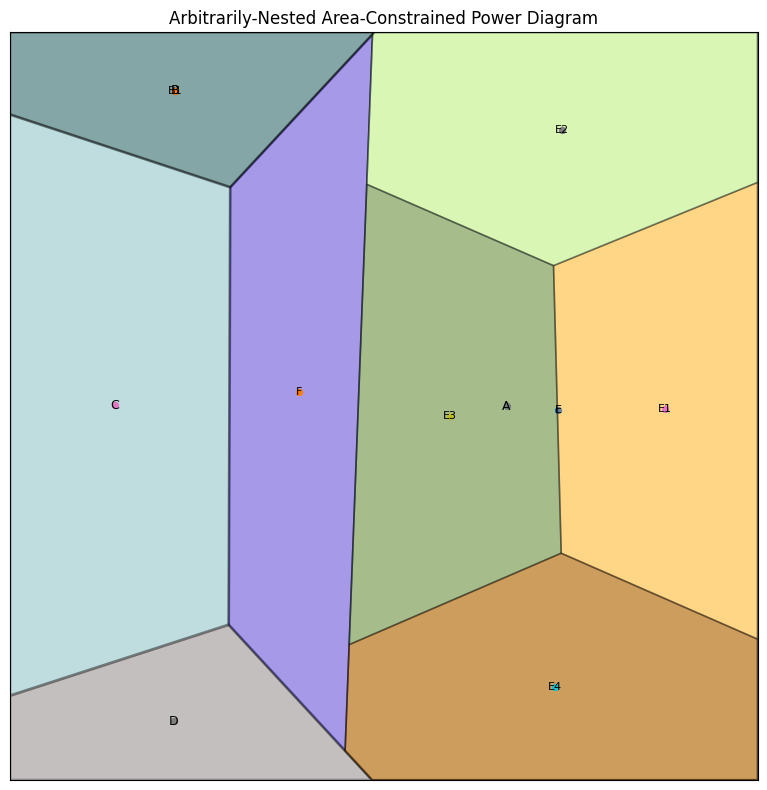

In [25]:

nested = {
    "A": {"children": {
        "E": {"children": {"E1": 1, "E2": 1, "E3": 1, "E4": 1}},
        "F": 1,
    }},
    "B": {"children": {
        "B1": 0.5,
        # "E": {"children": {"E1": 1, "E2": 1, "E3": 1, "E4": 1}},
    }},
    "C": 1.5,
    "D": 0.5,
}

Plotter(DiagramConfig()).plot(nested)
# Plotter(DiagramConfig()).plot(digraph_to_nested_children(G))